In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# Set directory paths
train_directory = "../data/train"
if not os.path.exists(train_directory):
    train_directory = "data/train"

test_directory = "../data/test"
if not os.path.exists(test_directory):
    test_directory = "data/test"

image_size = (224, 224)
batch_size = 32
class_names = ["ok_front", "def_front"]

# Load Datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

# Improve performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.


In [3]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [5]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.40),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model_save_path = "../models/best_casting_defect_model.keras"
if not os.path.exists("../models"):
    model_save_path = "models/best_casting_defect_model.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=0.000001),
    tf.keras.callbacks.ModelCheckpoint(filepath=model_save_path, monitor="val_loss", save_best_only=True)
]

Epoch 1/10


c:\Users\Harshitha\OneDrive\Desktop\Task 13 casting-quality-inspection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


166/166 ━━━━━━━━━━━━━━━━━━━━ 92s 544ms/step - accuracy: 0.5542 - loss: 0.6899 - precision: 0.5589 - recall: 0.9731 - val_accuracy: 0.5897 - val_loss: 0.6826 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 197s 874ms/step - accuracy: 0.5608 - loss: 0.6859 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6768 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 114s 686ms/step - accuracy: 0.5625 - loss: 0.6823 - precision: 0.5639 - recall: 0.9698 - val_accuracy: 0.5897 - val_loss: 0.6643 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 97s 582ms/step - accuracy: 0.5694 - loss: 0.6744 - precision: 0.5786 - recall: 0.8542 - val_accuracy: 0.6516 - val_loss: 0.6372 - val_precision: 0.6294 - val_recall: 0.9949 - learning_rate: 0.0010
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 98s 590ms/step - accu

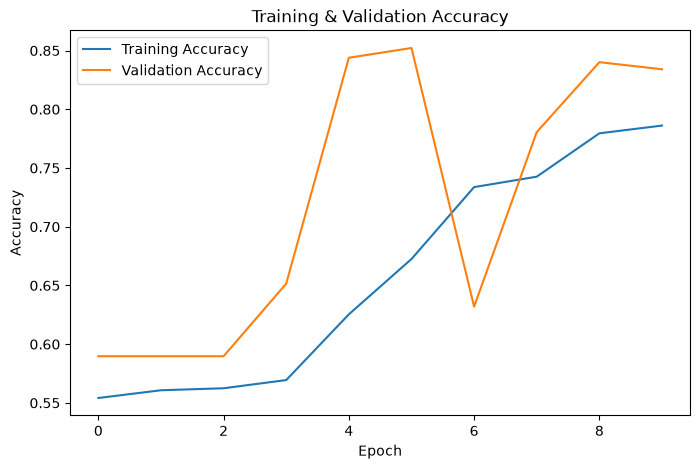

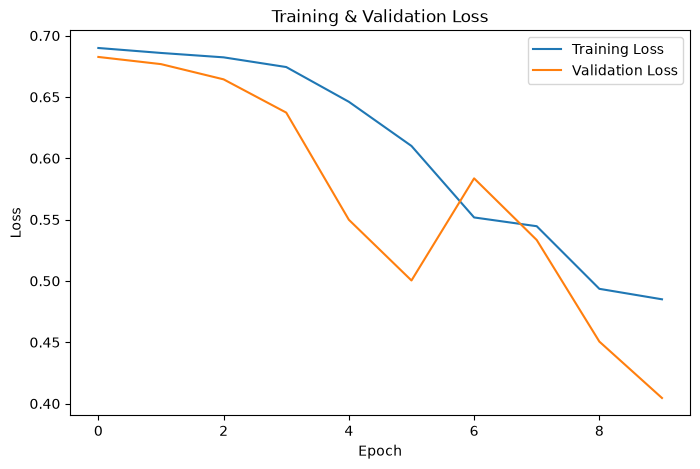

In [7]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=callbacks
)

# Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

# Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step
--- Classification Report ---
              precision    recall  f1-score   support

    ok_front       0.82      0.68      0.74       262
   def_front       0.83      0.92      0.87       453

    accuracy                           0.83       715
   macro avg       0.83      0.80      0.81       715
weighted avg       0.83      0.83      0.82       715



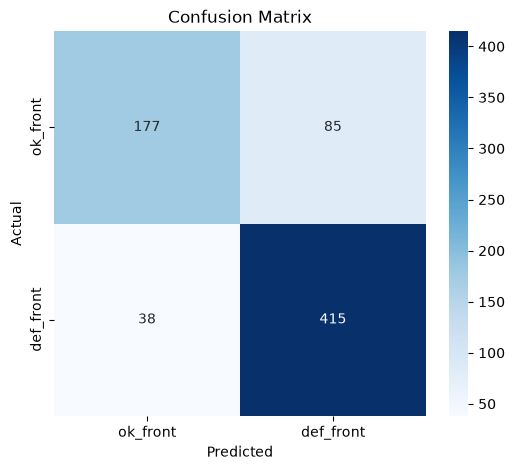

In [8]:
prediction_probabilities = model.predict(test_dataset).flatten()
actual_labels = np.concatenate([labels.numpy().flatten() for images, labels in test_dataset]).astype(int)
predicted_labels = (prediction_probabilities >= 0.50).astype(int)

print("--- Classification Report ---")
print(classification_report(actual_labels, predicted_labels, target_names=class_names))

cm = confusion_matrix(actual_labels, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
import os
import tensorflow as tf
from PIL import Image

def predict_product(image_path, model, threshold=0.50):

    try:
        # Verify that the file is a valid image
        with Image.open(image_path) as img:
            img.verify()

        # Load image
        image = tf.keras.utils.load_img(
            image_path,
            target_size=(224, 224)
        )

        image_array = tf.keras.utils.img_to_array(image)
        image_array = tf.expand_dims(image_array, axis=0)

        # Predict
        defect_probability = float(
            model.predict(image_array, verbose=0)[0][0]
        )

        if defect_probability >= threshold:
            predicted_class = "Defective (1)"
            recommended_action = "Send product for manual inspection"
        else:
            predicted_class = "Non-defective (0)"
            recommended_action = "Product may proceed on production line"

        print(f"Image: {os.path.basename(image_path)}")
        print(f"Prediction: {predicted_class}")
        print(f"Defect probability: {defect_probability:.2%}")
        print(f"Recommended action: {recommended_action}")

    except Exception as e:
        print(f"Unable to process: {image_path}")
        print(f"Reason: {e}")


sample_dir = "../sample_images"

if not os.path.exists(sample_dir):
    sample_dir = "sample_images"

sample_files = [
    os.path.join(sample_dir, f)
    for f in os.listdir(sample_dir)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

print("Sample images found:", len(sample_files))

for image_path in sample_files:
    print("\n" + "=" * 50)
    predict_product(image_path, model)

Sample images found: 10

Unable to process: ../sample_images\image1.jpg
Reason: cannot identify image file '../sample_images\\image1.jpg'

Unable to process: ../sample_images\image2.jpg
Reason: cannot identify image file '../sample_images\\image2.jpg'

Unable to process: ../sample_images\image3.jpg
Reason: cannot identify image file '../sample_images\\image3.jpg'

Unable to process: ../sample_images\image4.jpg
Reason: cannot identify image file '../sample_images\\image4.jpg'

Unable to process: ../sample_images\image5.jpg
Reason: cannot identify image file '../sample_images\\image5.jpg'

Image: sample_1_non_defective.jpeg
Prediction: Defective (1)
Defect probability: 62.27%
Recommended action: Send product for manual inspection

Image: sample_2_non_defective.jpeg
Prediction: Non-defective (0)
Defect probability: 20.26%
Recommended action: Product may proceed on production line

Image: sample_3_non_defective.jpeg
Prediction: Defective (1)
Defect probability: 50.55%
Recommended action: S

In [12]:
import os
import tensorflow as tf
from PIL import Image

def predict_product(image_path, model, threshold=0.50):

    try:
        # Check whether the file is a valid image
        with Image.open(image_path) as img:
            img.verify()

        image = tf.keras.utils.load_img(
            image_path,
            target_size=(224, 224)
        )

        image_array = tf.keras.utils.img_to_array(image)
        image_array = tf.expand_dims(image_array, axis=0)

        defect_probability = float(
            model.predict(image_array, verbose=0)[0][0]
        )

        if defect_probability >= threshold:
            predicted_class = "Defective (1)"
            recommended_action = "Send product for manual inspection"
        else:
            predicted_class = "Non-defective (0)"
            recommended_action = "Product may proceed on production line"

        print(f"Image: {os.path.basename(image_path)}")
        print(f"Prediction: {predicted_class}")
        print(f"Defect probability: {defect_probability:.2%}")
        print(f"Recommended action: {recommended_action}")

    except Exception as e:
        print(f"Unable to process: {image_path}")
        print(f"Reason: {e}")


sample_dir = "../sample_images"

sample_files = [
    os.path.join(sample_dir, f)
    for f in os.listdir(sample_dir)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

print("Valid sample files:", len(sample_files))

for image_path in sample_files:
    print("\n" + "=" * 50)
    predict_product(image_path, model)

Valid sample files: 10

Unable to process: ../sample_images\image1.jpg
Reason: cannot identify image file '../sample_images\\image1.jpg'

Unable to process: ../sample_images\image2.jpg
Reason: cannot identify image file '../sample_images\\image2.jpg'

Unable to process: ../sample_images\image3.jpg
Reason: cannot identify image file '../sample_images\\image3.jpg'

Unable to process: ../sample_images\image4.jpg
Reason: cannot identify image file '../sample_images\\image4.jpg'

Unable to process: ../sample_images\image5.jpg
Reason: cannot identify image file '../sample_images\\image5.jpg'

Image: sample_1_non_defective.jpeg
Prediction: Defective (1)
Defect probability: 62.27%
Recommended action: Send product for manual inspection

Image: sample_2_non_defective.jpeg
Prediction: Non-defective (0)
Defect probability: 20.26%
Recommended action: Product may proceed on production line

Image: sample_3_non_defective.jpeg
Prediction: Defective (1)
Defect probability: 50.55%
Recommended action: Se

In [13]:
import os

sample_dir = "../sample_images"

for filename in os.listdir(sample_dir):
    filepath = os.path.join(sample_dir, filename)
    print(filename, "->", os.path.getsize(filepath), "bytes")
    

image1.jpg -> 0 bytes
image2.jpg -> 0 bytes
image3.jpg -> 0 bytes
image4.jpg -> 0 bytes
image5.jpg -> 0 bytes
sample_1_non_defective.jpeg -> 6689 bytes
sample_2_non_defective.jpeg -> 5970 bytes
sample_3_non_defective.jpeg -> 6577 bytes
sample_4_non_defective.jpeg -> 6851 bytes
sample_5_non_defective.jpeg -> 6169 bytes
